# Notebook comunicante con github

Link alla repository GitHub: https://github.com/andrealuigipala-del/MLOps_sentiment_project

Il presente notebook è presente anche nella cartella "notebook" della repository GitHub.

In [1]:
# installazione dipendenze

!pip install transformers datasets torch pandas scikit-learn huggingface_hub -q

In [2]:
# clonazione repositary presente su guthub

!git clone https://github.com/andrealuigipala-del/MLOps_sentiment_project.git
%cd MLOps_sentiment_project

Cloning into 'MLOps_sentiment_project'...
remote: Enumerating objects: 600, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 600 (delta 72), reused 24 (delta 13), pack-reused 476 (from 2)
Receiving objects: 100% (600/600), 7.65 MiB | 9.58 MiB/s, done.
Resolving deltas: 100% (340/340), done.
/content/MLOps_sentiment_project


In [3]:
# import librerie e funzioni appena clonate da github

import os
import json
import random
import pandas as pd
import matplotlib.pyplot as plt
os.environ["WANDB_DISABLED"] = "true"

from scripts.preprocess import load_dataset
from scripts.train import fine_tune_model
from scripts.evaluate_and_save import evaluate_model

In [4]:
# caricamento dataset (script preprocessing.py), visibile pubblicamente,  e splitting di train e test

url = "https://raw.githubusercontent.com/andrealuigipala-del/MLOps_sentiment_project/refs/heads/main/data/src/Twitter_Data.csv"
X_train, X_test, y_train, y_test = load_dataset(url)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Dataset caricato: 130375 train, 32594 test
Train: 130375, Test: 32594


In [5]:
# Nota: ridotto a 500 campioni per limitare i tempi su Colab gratuito.
# Nella pipeline CI/CD su GitHub Actions vengono usati 2500 campioni.

trainer, model, tokenizer = fine_tune_model(
    X_train[:500], y_train[:500],
    X_test[:100],  y_test[:100]
)

save_path = "./data/results/trained_model"
os.makedirs(save_path, exist_ok=True)
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Modello salvato in {save_path}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.924638,0.610000
2,0.878200,0.835933,0.670000


Modello salvato in ./data/results/trained_model
Modello salvato in ./data/results/trained_model


In [6]:
# valutazione modello appena riaddestrato. Test di soli 100 campio per limitare tempo caricamento tokenizer.
# divisione in batch per necessità di risurre massima RAM disponibile su colab gratuitamente (12Gb)
# metriche modello pessime dovute al limitato bacino di addestramento, limitato dalle risorse disponibili gratuitamente! E al tempo necessario....

sample_size = 100
indices = random.sample(range(len(X_test)), sample_size)
X_test_small = X_test.iloc[indices].tolist()
y_test_small = y_test.iloc[indices].tolist()

f1, report = evaluate_model(save_path, X_test_small, y_test_small, batch_size=8)
print(f"F1 macro modello fine-tunato: {f1}")
print(report)

F1 macro modello fine-tunato: 0.4893
              precision    recall  f1-score   support

           0     0.3125    0.2500    0.2778        20
           1     0.5714    0.5161    0.5424        31
           2     0.6071    0.6939    0.6476        49

    accuracy                         0.5500       100
   macro avg     0.4970    0.4867    0.4893       100
weighted avg     0.5371    0.5500    0.5410       100



In [7]:
# valutazione modello ORIGINALE (HuggingFace Hub) per confronto rapido con modello retrained --> metriche peggiorano, come atteso

f1_base, report_base = evaluate_model(
    "cardiffnlp/twitter-roberta-base-sentiment-latest",
    X_test_small, y_test_small, batch_size=8
)
print(f"F1 macro modello base Cardiff: {f1_base}")
print(report_base)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


F1 macro modello base Cardiff: 0.3349
              precision    recall  f1-score   support

           0     0.2353    0.4000    0.2963        20
           1     0.3455    0.6129    0.4419        31
           2     0.7273    0.1633    0.2667        49

    accuracy                         0.3500       100
   macro avg     0.4360    0.3921    0.3349       100
weighted avg     0.5105    0.3500    0.3269       100



In [8]:
# deploy modello huggingface (esempio di utilizzo)

from scripts.deploy_huggingface import predict_sentiment

texts = [
    "MachineInnovators Inc. is amazing!",
    "Terrible experience with their support.",
    "It's okay, nothing special."
]

results = predict_sentiment(texts)
for r in results:
    print(f"[{r['sentiment'].upper()}] ({r['score']}) — {r['text']}")

tokenizer_config.json:   0%|          | 0.00/576 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/973 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Device set to use cuda:0


[POSITIVE] (0.985) — MachineInnovators Inc. is amazing!
[NEGATIVE] (0.9733) — Terrible experience with their support.
[POSITIVE] (0.9198) — It's okay, nothing special.


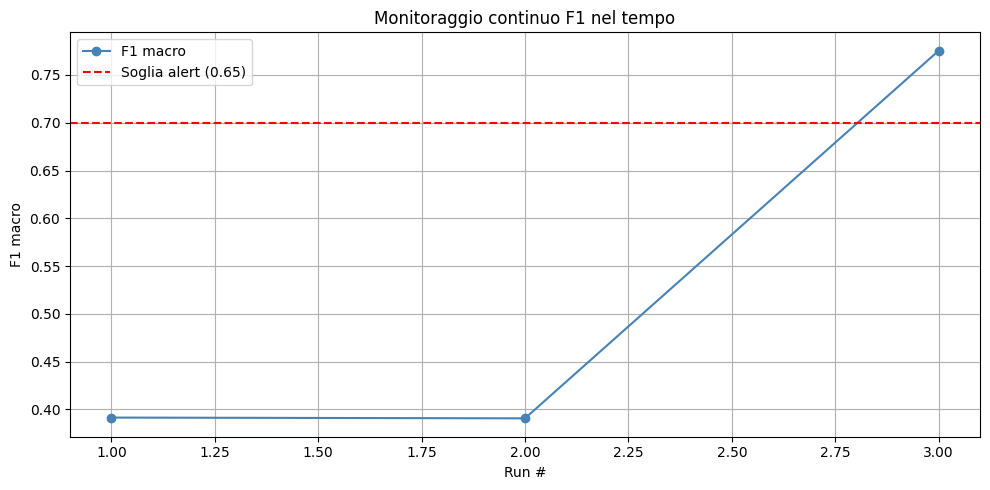


Totale run monitorati: 3
Run con alert: 0


In [9]:
# Carica il log di monitoring salvato nel repo
log_url = "https://raw.githubusercontent.com/andrealuigipala-del/MLOps_sentiment_project/refs/heads/main/data/monitoring/metrics_log.json"

import urllib.request
with urllib.request.urlopen(log_url) as f:
    log = json.load(f)

runs   = [entry["run"] for entry in log]
f1s    = [entry["f1_macro"] for entry in log]
alerts = [entry["alert"] for entry in log]

plt.figure(figsize=(10, 5))
plt.plot(runs, f1s, marker='o', color='steelblue', label='F1 macro')
plt.axhline(y=0.7, color='red', linestyle='--', label='Soglia alert (0.65)')

for i, alert in enumerate(alerts):
    if alert:
        plt.scatter(runs[i], f1s[i], color='red', zorder=5, s=100)

plt.title('Monitoraggio continuo F1 nel tempo')
plt.xlabel('Run #')
plt.ylabel('F1 macro')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nTotale run monitorati: {len(log)}")
print(f"Run con alert: {sum(alerts)}")